In [21]:
import numpy as np
from scipy.interpolate import griddata
import os
from matplotlib.colors import LogNorm

import matplotlib.pyplot as plt
import prodimopy.read as pread
import prodimopy.plot as pplot
import scipy.interpolate as interp
#!pip install prodimopy

# Load a valid style
pplot.load_style('default')  # Replace 'default' with the correct style name or path if needed

In [22]:
TextFileName='Ionisation_Rate_MapTTauriLargePublication.txt'
TransportDiscModelDir="../TTauriJWST_Large"
FinalDiscModelDir="../TTauriJWST_Large"
InitialDiscModelName="TTauriJWST_Large"
TransportDiscModel=pread.read_prodimo(TransportDiscModelDir)
Finalmodel=pread.read_prodimo(FinalDiscModelDir)

Kappa=1

READ: Reading File:  ../TTauriJWST_Large/ProDiMo.out  ...
READ: Reading File:  ../TTauriJWST_Large/Species.out  ...


/opt/anaconda3/envs/newenv/lib/python3.10/site-packages/prodimopy/read.py:2751: DeprecationWarning: `np.chararray` is deprecated and will be removed from the main namespace in the future. Use an array with a string or bytes dtype instead.
  data._radFields_cache=np.chararray(shape=(data.nx,data.nz,data.nlam),itemsize=13)
/opt/anaconda3/envs/newenv/lib/python3.10/site-packages/prodimopy/read.py:2752: DeprecationWarning: `np.chararray` is deprecated and will be removed from the main namespace in the future. Use an array with a string or bytes dtype instead.
  data._nmol_cache=np.chararray((data.nx,data.nz,data.nspec),itemsize=13)
/opt/anaconda3/envs/newenv/lib/python3.10/site-packages/prodimopy/read.py:2753: DeprecationWarning: `np.chararray` is deprecated and will be removed from the main namespace in the future. Use an array with a string or bytes dtype instead.
  data._heat_cache=np.chararray((data.nx,data.nz,data.nheat),itemsize=13)
/opt/anaconda3/envs/newenv/lib/python3.10/site-pack

WARN: Could not open ../TTauriJWST_Large/FlineEstimates.out!
READ: Reading File:  ../TTauriJWST_Large/Elements.out  ...
READ: Reading File:  ../TTauriJWST_Large/dust_opac.out  ...
READ: Reading File:  ../TTauriJWST_Large/dust_sigmaa.out  ...
READ: Reading File:  ../TTauriJWST_Large/StarSpectrum.out  ...
READ: Reading File:  ../TTauriJWST_Large/line_flux.out  ...
READ: Reading File:  ../TTauriJWST_Large/SED.out  ...
READ: Reading File:  ../TTauriJWST_Large/SEDana.out  ...
READ: Reading File:  ../TTauriJWST_Large/image.out  ...
READ: Reading File:  ../TTauriJWST_Large/Parameter.out  ...
INFO: Reading time:  0.41 s
 
READ: Reading File:  ../TTauriJWST_Large/ProDiMo.out  ...
READ: Reading File:  ../TTauriJWST_Large/Species.out  ...


/opt/anaconda3/envs/newenv/lib/python3.10/site-packages/prodimopy/read.py:2331: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  self._Lbols[self.__incidx]=np.trapz(self.fnuErg[mask],x=self.nu[mask])*-1.0
/opt/anaconda3/envs/newenv/lib/python3.10/site-packages/prodimopy/read.py:2337: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  self._Tbols[self.__incidx]=1.25e-11*np.trapz((self.nu[mask]*self.fnuErg[mask]),x=self.nu[mask])/np.trapz(self.fnuErg[mask],x=self.nu[mask])


WARN: Could not open ../TTauriJWST_Large/FlineEstimates.out!
READ: Reading File:  ../TTauriJWST_Large/Elements.out  ...
READ: Reading File:  ../TTauriJWST_Large/dust_opac.out  ...
READ: Reading File:  ../TTauriJWST_Large/dust_sigmaa.out  ...
READ: Reading File:  ../TTauriJWST_Large/StarSpectrum.out  ...
READ: Reading File:  ../TTauriJWST_Large/line_flux.out  ...
READ: Reading File:  ../TTauriJWST_Large/SED.out  ...
READ: Reading File:  ../TTauriJWST_Large/SEDana.out  ...
READ: Reading File:  ../TTauriJWST_Large/image.out  ...
READ: Reading File:  ../TTauriJWST_Large/Parameter.out  ...
INFO: Reading time:  0.39 s
 


In [23]:

def plotQuantity(Aml,grilleXAUliste,grilleZAUliste,vmin,vmax,name):
    plt.figure(figsize=(8, 6))
    #grilleXAUliste= Initialmodel.x
    #grilleZAUliste= Initialmodel.z
    plt.pcolor(grilleXAUliste, grilleZAUliste/grilleXAUliste, Aml, cmap='viridis', norm=LogNorm(vmin=vmin, vmax=vmax))
    #plt.pcolor(grilleXAUliste, grilleZAUliste/grilleXAUliste, Aml, cmap='viridis', vmin=vmin, vmax=vmax)
    
    plt.xlabel('R (au)',fontsize=18)
    plt.ylabel('$Z/R$',fontsize=18)
    #plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste,alpha, cmap='viridis', norm=LogNorm(0.1, 1))
    # Write the value of the contour line on the plot
    
    cb=plt.colorbar(label=str(name))
    cb.set_label(label=str(name), size=18)
    
    
    cb.ax.tick_params(labelsize=15)
    contour_levels = [ 0.99]
    
    #plt.clabel(contours, fontsize=10)

#plt.clabel(contours, fontsize=10)
    #cb.set_label(label='1E-6', size=15)
    #plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste,Aml, cmap='viridis')
    #cb.set_label(label=str(name), size=15)
    #plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste, Rml, [0,1000])
    #plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste, Aml, [1E-1,1E30])
    #plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste, Rml, [3000,1E30])
    plt.ylim(0,0.5)
    
    plt.xscale('log')
    #plt.xlim(0.07,630)
    #plt.xlim(0.07,1)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    #plt.ylim(0.05,0.25)
    #plt.title('Ionization plot')
    plt.show()


In [24]:

def Read_Ionisation_Map_Text_File(TextFileName):
    # Create the text file
    filename = TextFileName
    
    Propagated_Flux = []
    # Read Propagated_Flux_Electron from the text file
    Nlist=[]
    Propagated_Flux=[]
    with open(filename, "r") as file:
        F=file.read()
        file.close()
    F=F.split('\n')
    Propagated_Flux=np.loadtxt(filename, delimiter=',')
    return Propagated_Flux
    

alpha=4.3
Emax=1.5*1E7

Zeta=Kappa*Read_Ionisation_Map_Text_File(TextFileName)
#print(Zeta[30])


print((Zeta))
# This is for new file using the vertical column density
#inFileV="Ionisation_Rate_Mapalpha=3.7Emax=1.5e+07CIW98_XN_AH_CIK.txt"
#inFileV="IonizationCoronalFlares.txt"
#zetaFlare=np.loadtxt(inFileV)
#print(zetaFlare[:,1].shape)


[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 9.11611777e-21
  9.11621851e-21 9.11626410e-21]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 9.45729194e-25
  9.45729972e-25 9.45730109e-25]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 8.88436578e-25
  8.88436676e-25 8.88436721e-25]
 ...
 [0.00000000e+00            nan            nan ...            nan
             nan            nan]
 [0.00000000e+00            nan            nan ...            nan
             nan            nan]
 [0.00000000e+00            nan            nan ...            nan
             nan            nan]]


In [25]:


#ReductionFactor=10

x=TransportDiscModel.x
z=TransportDiscModel.z
#x=np.reshape(x,(nr,nz),order="F")
#print(x[:,0])
#z=np.reshape(z,(nr,nz),order="F")
#print(np.max(x))

xfin=Finalmodel.x
zfin=Finalmodel.z

print(xfin.shape)
print(zfin.shape)
print(Zeta.shape)
print(x.shape)


ZetaFin=griddata((x.flatten(), z.flatten()), Zeta.flatten(), (xfin, zfin), method='linear')
ZetaFin[np.isnan(ZetaFin)]=0
#f = interp.interp2d(x, z, Zeta, kind='linear')

np.savetxt(TextFileName.replace(".txt", f"_Kappa{Kappa}.in"), ZetaFin)

#zeta[zeta<1.e-100]=1.e-30

# set all zero value to nan ... otherwise probs with log
#Zeta[Zeta<1.e-100]=np.nan


(100, 100)
(100, 100)
(100, 100)
(100, 100)


/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_52020/56487152.py:2: RuntimeWarning: divide by zero encountered in log10
  ax.contourf(xfin,zfin/xfin,np.log10(ZetaFin),levels=20,vmin=-22,vmax=-6)
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_52020/56487152.py:2: RuntimeWarning: invalid value encountered in log10
  ax.contourf(xfin,zfin/xfin,np.log10(ZetaFin),levels=20,vmin=-22,vmax=-6)
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_52020/56487152.py:3: RuntimeWarning: divide by zero encountered in log10
  cbar = plt.colorbar(ax.contourf(xfin,zfin/xfin,np.log10(ZetaFin), levels=20,vmin=-22,vmax=-6), ax=ax)
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_52020/56487152.py:3: RuntimeWarning: invalid value encountered in log10
  cbar = plt.colorbar(ax.contourf(xfin,zfin/xfin,np.log10(ZetaFin), levels=20,vmin=-22,vmax=-6), ax=ax)


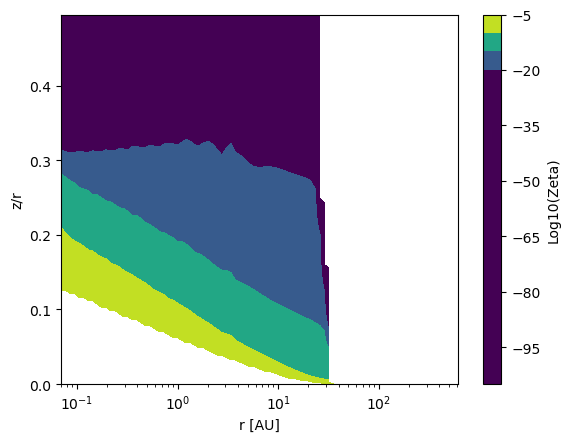

In [26]:



fig,ax=plt.subplots(1,1)
ax.contourf(xfin,zfin/xfin,np.log10(ZetaFin),levels=20,vmin=-22,vmax=-6)
cbar = plt.colorbar(ax.contourf(xfin,zfin/xfin,np.log10(ZetaFin), levels=20,vmin=-22,vmax=-6), ax=ax)
#cbar.set_ticks(np.linspace(-22, -6, num=9))

cbar.set_label('Log10(Zeta)')
ax.set_xlabel('r [AU]')
ax.set_ylabel('z/r')
plt.xscale('log')
plt.show()
#ax.invert_yaxis()
#ax.semilogy()
